# Wine Quality Classification

## Reference workflow

This notebook predicts discrete wine-quality scores from physicochemical measurements. It checks data quality and class balance, removes duplicate rows, splits and scales the features, then compares shared classifiers. Run it from top to bottom; outputs are saved in `../Results/`.

In [1]:
# Import the data, plotting, and numerical tools used throughout the analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load physicochemical measurements together with the quality-score target.
df = pd.read_csv("../Data/wine_quality.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.shape

(1599, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [6]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

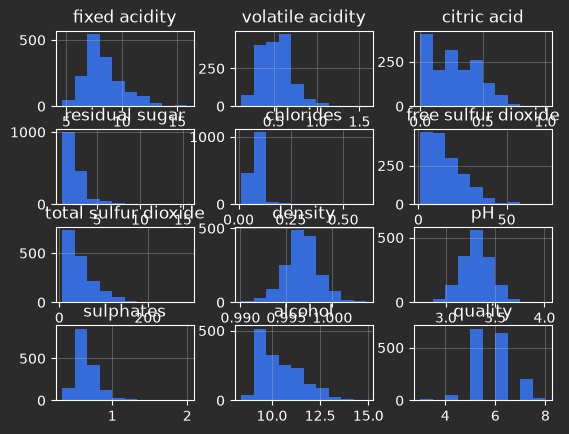

In [7]:
df.hist()

In [8]:
missing_value_counts = df.isnull().sum()
missing_value_counts

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [9]:
duplicate_values = df.duplicated().sum()
print(duplicate_values)

240


In [10]:
# Remove repeated records so they do not bias model fitting or reported metrics.
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [11]:
df.shape

(1359, 12)

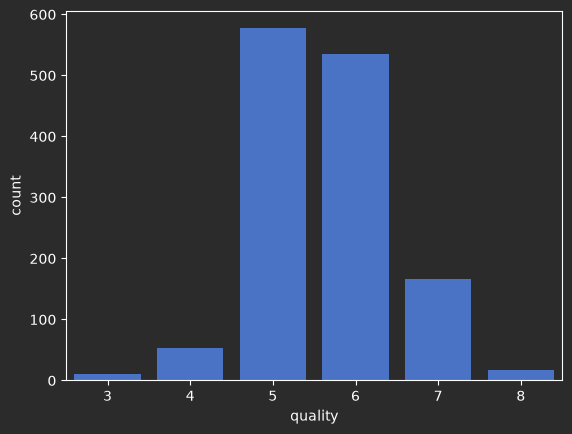

In [12]:
sns.countplot(x = 'quality', data = df)
plt.show()

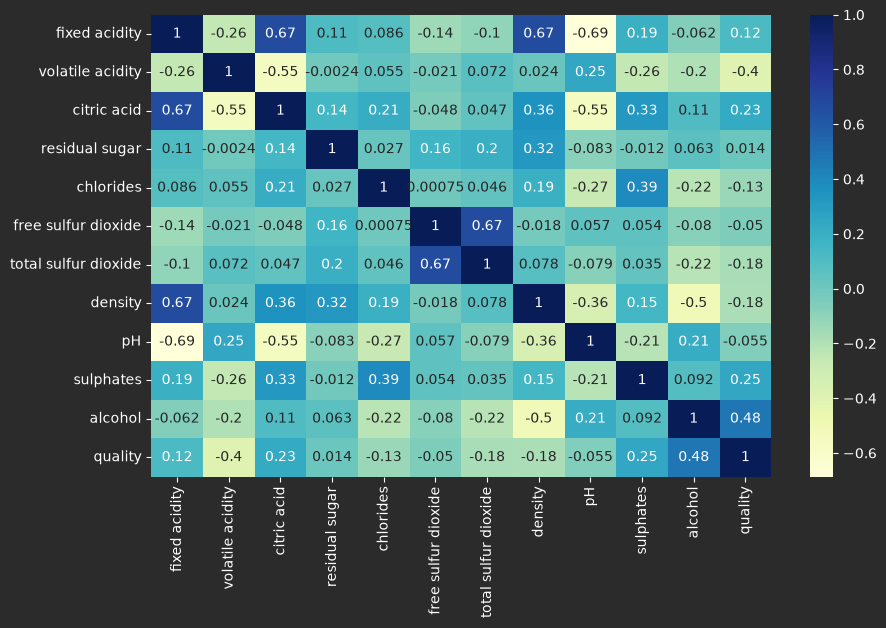

In [13]:
plt.figure(figsize= (10, 6))
sns.heatmap(df.corr(), annot = True,cmap = 'YlGnBu')
plt.show()

In [14]:
# Separate measurements from the quality score that models must predict.
X = df.drop("quality", axis=1)
Y = df["quality"]

In [15]:
from utils.preprocessing import split_data, scale_data

# Preserve score frequencies in the split and prevent test data leaking into scaling.
X_train, X_test, Y_train, Y_test = split_data(X, Y)

X_train_scaled, X_test_scaled = scale_data(
    X_train,
    X_test
)

Saving confusion matrix to: ../Results/confusion_matrices\Wine_Quality_logistic_regression.png


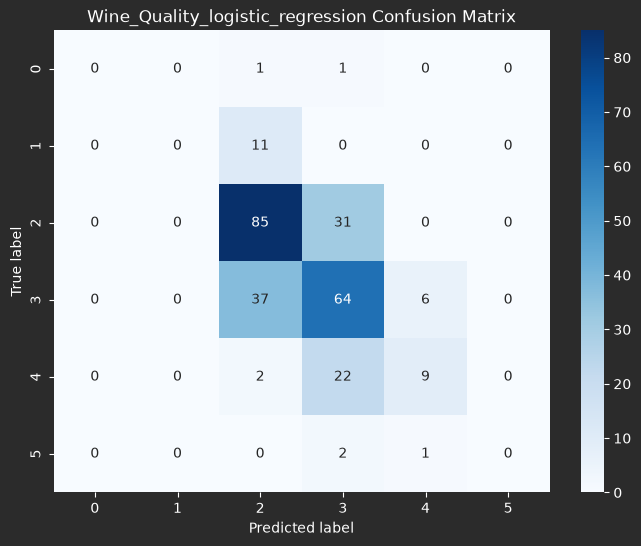


Classification Report - logistic_regression
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       116
           6       0.53      0.60      0.56       107
           7       0.56      0.27      0.37        33
           8       0.00      0.00      0.00         3

    accuracy                           0.58       272
   macro avg       0.29      0.27      0.27       272
weighted avg       0.54      0.58      0.55       272

Saving JSON to: ../Results/Wine_Quality_logistic_regression_20260814_174423.json

Model: logistic_regression
{'accuracy': 0.5808823529411765, 'precision': 0.5445925245098039, 'recall': 0.5808823529411765, 'f1': 0.5540853639546862, 'confusion_matrix': [[0, 0, 1, 1, 0, 0], [0, 0, 11, 0, 0, 0], [0, 0, 85, 31, 0, 0], [0, 0, 37, 64, 6, 0], [0, 0, 2, 22, 9, 0], [0, 0, 0, 2, 1, 0]], 'classification_report': {'3': {'

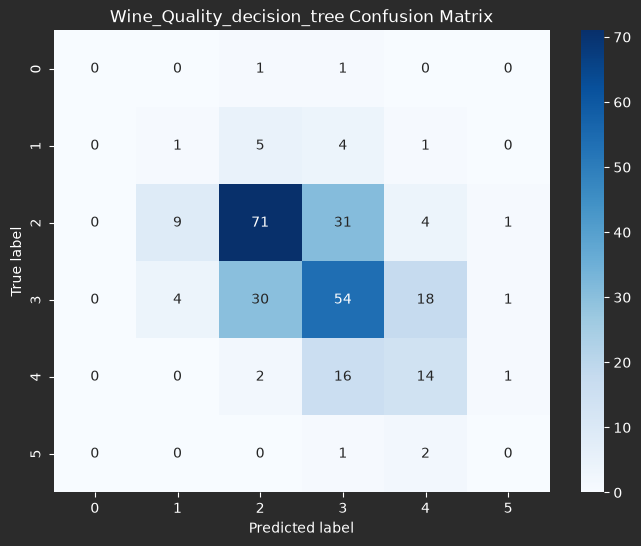


Classification Report - decision_tree
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.07      0.09      0.08        11
           5       0.65      0.61      0.63       116
           6       0.50      0.50      0.50       107
           7       0.36      0.42      0.39        33
           8       0.00      0.00      0.00         3

    accuracy                           0.51       272
   macro avg       0.26      0.27      0.27       272
weighted avg       0.52      0.51      0.52       272

Saving JSON to: ../Results/Wine_Quality_decision_tree_20260814_174423.json

Model: decision_tree
{'accuracy': 0.5147058823529411, 'precision': 0.522762871909526, 'recall': 0.5147058823529411, 'f1': 0.5180964052287581, 'confusion_matrix': [[0, 0, 1, 1, 0, 0], [0, 1, 5, 4, 1, 0], [0, 9, 71, 31, 4, 1], [0, 4, 30, 54, 18, 1], [0, 0, 2, 16, 14, 1], [0, 0, 0, 1, 2, 0]], 'classification_report': {'3': {'precision': 0.0, '

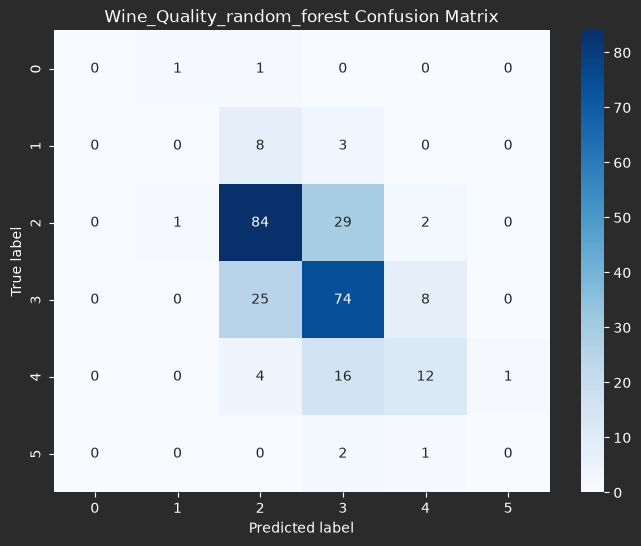


Classification Report - random_forest
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.72      0.71       116
           6       0.60      0.69      0.64       107
           7       0.52      0.36      0.43        33
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.30      0.30      0.30       272
weighted avg       0.59      0.62      0.61       272

Saving JSON to: ../Results/Wine_Quality_random_forest_20260814_174424.json

Model: random_forest
{'accuracy': 0.625, 'precision': 0.5916951561508883, 'recall': 0.625, 'f1': 0.6050710391108316, 'confusion_matrix': [[0, 1, 1, 0, 0, 0], [0, 0, 8, 3, 0, 0], [0, 1, 84, 29, 2, 0], [0, 0, 25, 74, 8, 0], [0, 0, 4, 16, 12, 1], [0, 0, 0, 2, 1, 0]], 'classification_report': {'3': {'precision': 0.0, 'recall': 0.0, 'f1-score': 

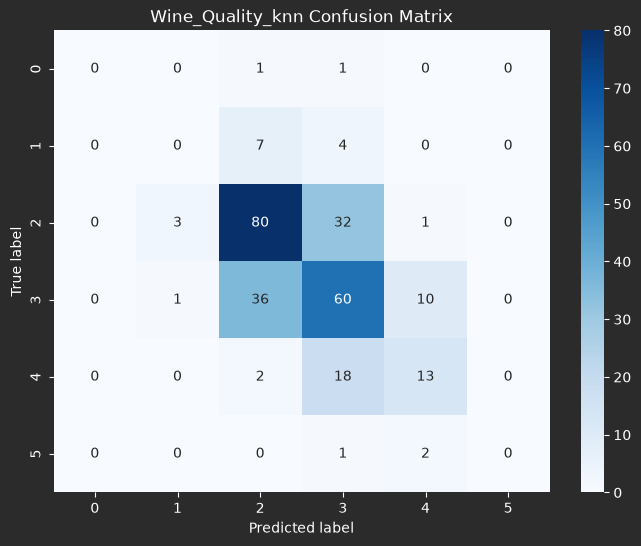


Classification Report - knn
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.63      0.69      0.66       116
           6       0.52      0.56      0.54       107
           7       0.50      0.39      0.44        33
           8       0.00      0.00      0.00         3

    accuracy                           0.56       272
   macro avg       0.28      0.27      0.27       272
weighted avg       0.53      0.56      0.55       272

Saving JSON to: ../Results/Wine_Quality_knn_20260814_174424.json

Model: knn
{'accuracy': 0.5625, 'precision': 0.5349103721948549, 'recall': 0.5625, 'f1': 0.5471142025504113, 'confusion_matrix': [[0, 0, 1, 1, 0, 0], [0, 0, 7, 4, 0, 0], [0, 3, 80, 32, 1, 0], [0, 1, 36, 60, 10, 0], [0, 0, 2, 18, 13, 0], [0, 0, 0, 1, 2, 0]], 'classification_report': {'3': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 2.0}, '4': 

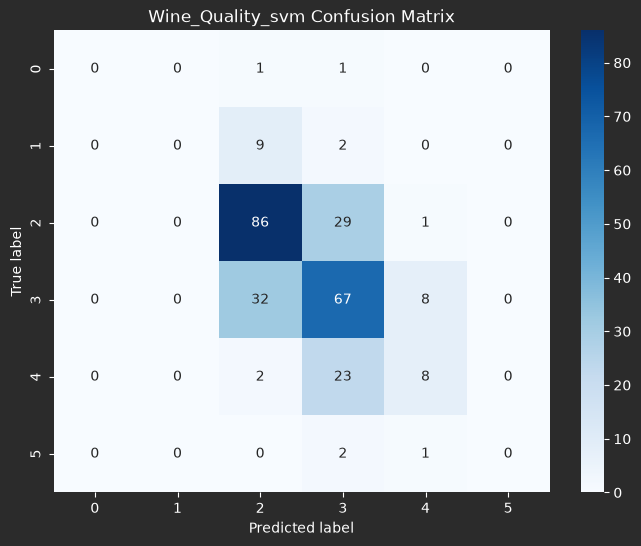


Classification Report - svm
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.66      0.74      0.70       116
           6       0.54      0.63      0.58       107
           7       0.44      0.24      0.31        33
           8       0.00      0.00      0.00         3

    accuracy                           0.59       272
   macro avg       0.27      0.27      0.27       272
weighted avg       0.55      0.59      0.56       272

Saving JSON to: ../Results/Wine_Quality_svm_20260814_174425.json

Model: svm
{'accuracy': 0.5919117647058824, 'precision': 0.5486016335814723, 'recall': 0.5919117647058824, 'f1': 0.5644407952303133, 'confusion_matrix': [[0, 0, 1, 1, 0, 0], [0, 0, 9, 2, 0, 0], [0, 0, 86, 29, 1, 0], [0, 0, 32, 67, 8, 0], [0, 0, 2, 23, 8, 0], [0, 0, 0, 2, 1, 0]], 'classification_report': {'3': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 

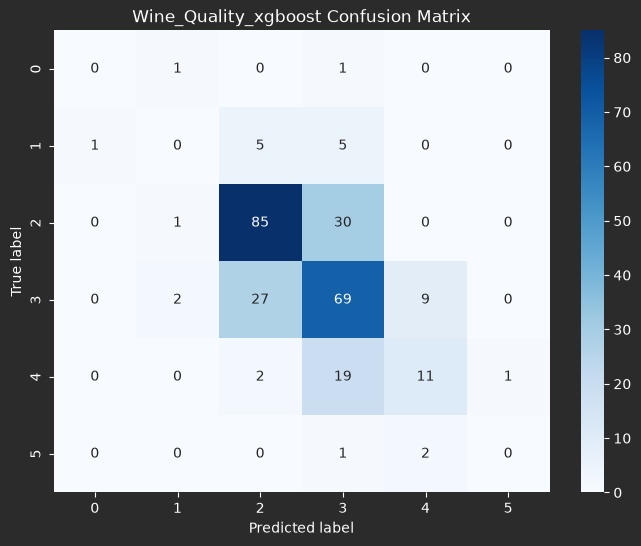


Classification Report - xgboost
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.73      0.72       116
           6       0.55      0.64      0.59       107
           7       0.50      0.33      0.40        33
           8       0.00      0.00      0.00         3

    accuracy                           0.61       272
   macro avg       0.29      0.29      0.29       272
weighted avg       0.58      0.61      0.59       272

Saving JSON to: ../Results/Wine_Quality_xgboost_20260814_174426.json

Model: xgboost
{'accuracy': 0.6066176470588235, 'precision': 0.5824306722689075, 'recall': 0.6066176470588235, 'f1': 0.5910347255189676, 'confusion_matrix': [[0, 1, 0, 1, 0, 0], [1, 0, 5, 5, 0, 0], [0, 1, 85, 30, 0, 0], [0, 2, 27, 69, 9, 0], [0, 0, 2, 19, 11, 1], [0, 0, 0, 1, 2, 0]], 'classification_report': {'3': {'precision': 0.0, 'recall': 0.0, 'f1-

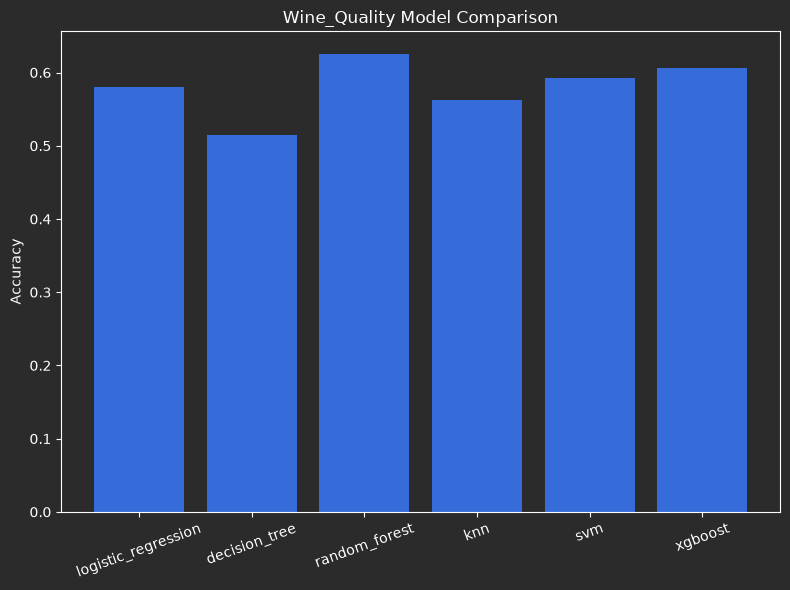

In [16]:
from Models.pipeline import run_pipeline
from utils.logger import save_accuracy_table
from utils.visualization import plot_accuracy_graph

dataset_name = "Wine_Quality"

models = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "knn",
    "svm",
    "xgboost"
]

all_results = []

# Run all candidates against the same data split for comparable results.
for model in models:

    results = run_pipeline(
        X_train,
        X_test,
        X_train_scaled,
        X_test_scaled,
        Y_train,
        Y_test,
        model,
        "Wine_Quality"
    )

    all_results.append({
        "Model": model,
        "Accuracy": results["accuracy"],
        "Precision": results["precision"],
        "Recall": results["recall"],
        "F1": results["f1"]
    })

    print(f"\n{'='*50}")
    print(f"Model: {model}")
    print(results)

save_accuracy_table(dataset_name, all_results)
plot_accuracy_graph(dataset_name, all_results)

In [17]:
# Find best model based on accuracy
best_model = max(
    all_results,
    key=lambda x: x["Accuracy"]
)

print("\n" + "=" * 60)
print("BEST PERFORMING MODEL")
print("=" * 60)

print(f"Dataset   : {dataset_name}")
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1 Score  : {best_model['F1']:.4f}")


BEST PERFORMING MODEL
Dataset   : Wine_Quality
Model     : random_forest
Accuracy  : 0.6250
Precision : 0.5917
Recall    : 0.6250
F1 Score  : 0.6051
